In [1]:
# iot-shield | Network Intrusion Detection for IoT/Embedded Systems
# Phase 1 — Data Loading & Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


In [2]:
# Phase 2 — Load & Explore the Dataset

# NSL-KDD column names
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty'
]

# Load data
train_df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test_df = pd.read_csv('../data/KDDTest+.txt', names=columns)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"\nAttack types found:\n{train_df['attack_type'].value_counts()}")

Training samples: 125973
Testing samples: 22544

Attack types found:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [3]:
# Phase 3 — Preprocessing

# Binary classification — normal vs attack
train_df['label'] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

# Drop columns we don't need
train_df = train_df.drop(['attack_type', 'difficulty'], axis=1)
test_df = test_df.drop(['attack_type', 'difficulty'], axis=1)

# Encode categorical columns
le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Features and labels
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"Attack ratio in training: {y_train.mean():.2%}")
print("Preprocessing complete ✓")

X_train shape: (125973, 41)
Attack ratio in training: 46.54%
Preprocessing complete ✓


In [4]:
# Phase 4 — Model Training

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import time

# Decision Tree
print("Training Decision Tree...")
start = time.time()
dt_model = DecisionTreeClassifier(random_state=42, max_depth=20)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Decision Tree trained in {dt_time:.2f}s ✓")

# Random Forest
print("\nTraining Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
print(f"Random Forest trained in {rf_time:.2f}s ✓")

Training Decision Tree...
Decision Tree trained in 0.46s ✓

Training Random Forest...
Random Forest trained in 1.09s ✓


In [5]:
# Phase 5 — Evaluation

# Decision Tree
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=" * 50)
print(f"  DECISION TREE  Accuracy: {dt_acc:.4%}")
print("=" * 50)
print(classification_report(y_test, dt_pred, target_names=['Normal', 'Attack']))

print("=" * 50)
print(f"  RANDOM FOREST  Accuracy: {rf_acc:.4%}")
print("=" * 50)
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Attack']))

  DECISION TREE  Accuracy: 79.4358%
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
      Attack       0.97      0.66      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544

  RANDOM FOREST  Accuracy: 77.0671%
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [6]:
# Phase 6 — Improve with Scaling + Tuning

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tuned Random Forest
print("Training Tuned Random Forest...")
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # this fixes the attack recall problem
)
rf_tuned.fit(X_train_scaled, y_train)
rf_tuned_pred = rf_tuned.predict(X_test_scaled)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)

print("=" * 50)
print(f"  TUNED RANDOM FOREST  Accuracy: {rf_tuned_acc:.4%}")
print("=" * 50)
print(classification_report(y_test, rf_tuned_pred, target_names=['Normal', 'Attack']))

Training Tuned Random Forest...
  TUNED RANDOM FOREST  Accuracy: 77.0050%
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [8]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("=" * 50)
print(f"  XGBOOST  Accuracy: {xgb_acc:.4%}")
print("=" * 50)
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Attack']))

Training XGBoost...
  XGBOOST  Accuracy: 80.4161%
              precision    recall  f1-score   support

      Normal       0.70      0.97      0.81      9711
      Attack       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [9]:
# Phase 8 — Final Push with Voting Ensemble

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

print("Training Voting Ensemble...")

# Best models combined
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=30, random_state=42, n_jobs=-1
)
dt_final = DecisionTreeClassifier(max_depth=20, random_state=42)
xgb_final = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

ensemble = VotingClassifier(
    estimators=[('rf', rf_final), ('dt', dt_final), ('xgb', xgb_final)],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train_scaled, y_train)
ens_pred = ensemble.predict(X_test_scaled)
ens_acc = accuracy_score(y_test, ens_pred)

print("=" * 50)
print(f"  ENSEMBLE  Accuracy: {ens_acc:.4%}")
print("=" * 50)
print(classification_report(y_test, ens_pred, target_names=['Normal', 'Attack']))

Training Voting Ensemble...
  ENSEMBLE  Accuracy: 78.5353%
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.79      0.78     22544



In [10]:
# Phase 9 — Save the best model

import pickle

# XGBoost was our best at 80.4%
with open('iot_shield_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save the scaler too — needed for inference
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as iot_shield_model.pkl ✓")
print("Scaler saved as scaler.pkl ✓")

Model saved as iot_shield_model.pkl ✓
Scaler saved as scaler.pkl ✓


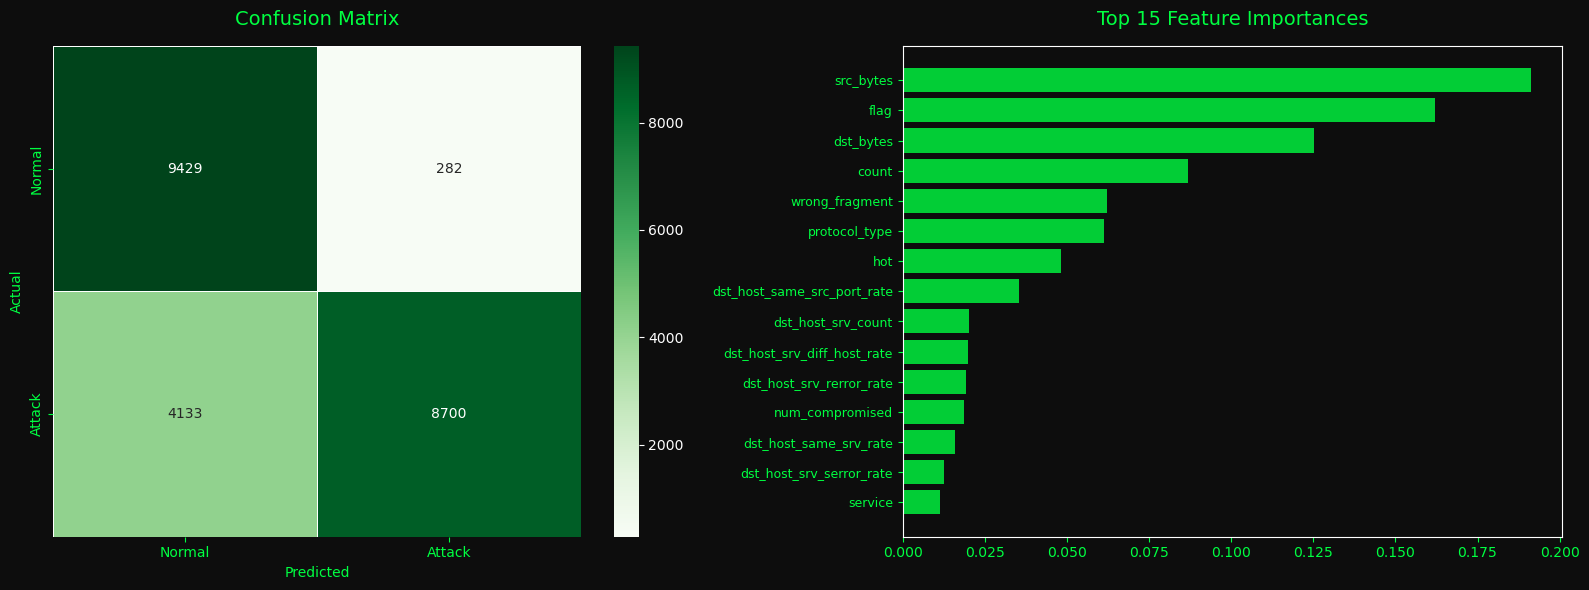

Visualisation saved to assets/ ✓


In [11]:
# Phase 10 — Visualisations

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set style
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0d')

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Confusion Matrix', color='#00FF41', fontsize=14, pad=15)
axes[0].set_ylabel('Actual', color='#00FF41')
axes[0].set_xlabel('Predicted', color='#00FF41')
axes[0].tick_params(colors='#00FF41')

# --- Feature Importance ---
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15
features = X_train.columns[indices]

axes[1].barh(range(15), importances[indices][::-1], color='#00FF41', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(features[::-1], color='#00FF41', fontsize=9)
axes[1].set_title('Top 15 Feature Importances', color='#00FF41', fontsize=14, pad=15)
axes[1].tick_params(colors='#00FF41')
axes[1].set_facecolor('#0d0d0d')

plt.tight_layout()
plt.savefig('../assets/model_performance.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Visualisation saved to assets/ ✓")